In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

## Fine Tuning a model on a "token classification" task

In [2]:
! pip install transformers seqeval evaluate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.8 MB/s eta 0:00:00
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=525d6676a8eafd82587406e77afead4ec428a0c74a6dee744cc2cbec9f282ab3
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval


In [3]:
!pip uninstall -y datasets
!pip install datasets==2.18.0 seqeval -q

Found existing installation: datasets 4.8.3
Uninstalling datasets-4.8.3:
  Successfully uninstalled datasets-4.8.3
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.5/510.5 kB 9.3 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 14.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
s3fs 2026.2.0 requires fsspec==2026.2.0, but you have fsspec 2024.2.0 which is incompatible.
tpot 1.1.0 requires dill>=0.3.9, but you have dill 0.3.8 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.2.0 which is incompatible.


In [4]:
import transformers

print(transformers.__version__)


5.0.0


In [5]:
task = "ner" # Should be one of "ner", "pos" or "chunk"
model_checkpoint = "distilbert-base-uncased"
batch_size = 16

### Load dataset

In [6]:
from datasets import load_dataset

datasets = load_dataset("conll2003")
print(datasets)

/usr/local/lib/python3.12/dist-packages/datasets/load.py:1461: FutureWarning: The repository for conll2003 contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/conll2003
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this dataset from the next major release of `datasets`.
  warnings.warn(


Generating train split:   0%|          | 0/14041 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3250 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3453 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 14041
    })
    validation: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3453
    })
})


In [7]:
datasets

DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 14041
    })
    validation: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3453
    })
})

In [8]:
datasets["train"][4]

{'id': '4',
 'tokens': ['Germany',
  "'s",
  'representative',
  'to',
  'the',
  'European',
  'Union',
  "'s",
  'veterinary',
  'committee',
  'Werner',
  'Zwingmann',
  'said',
  'on',
  'Wednesday',
  'consumers',
  'should',
  'buy',
  'sheepmeat',
  'from',
  'countries',
  'other',
  'than',
  'Britain',
  'until',
  'the',
  'scientific',
  'advice',
  'was',
  'clearer',
  '.'],
 'pos_tags': [22,
  27,
  21,
  35,
  12,
  22,
  22,
  27,
  16,
  21,
  22,
  22,
  38,
  15,
  22,
  24,
  20,
  37,
  21,
  15,
  24,
  16,
  15,
  22,
  15,
  12,
  16,
  21,
  38,
  17,
  7],
 'chunk_tags': [11,
  11,
  12,
  13,
  11,
  12,
  12,
  11,
  12,
  12,
  12,
  12,
  21,
  13,
  11,
  12,
  21,
  22,
  11,
  13,
  11,
  1,
  13,
  11,
  17,
  11,
  12,
  12,
  21,
  1,
  0],
 'ner_tags': [5,
  0,
  0,
  0,
  0,
  3,
  4,
  0,
  0,
  0,
  1,
  2,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  5,
  0,
  0,
  0,
  0,
  0,
  0,
  0]}

In [9]:
datasets["train"].features[f"ner_tags"]

Sequence(feature=ClassLabel(names=['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC'], id=None), length=-1, id=None)

In [10]:
label_list = datasets["train"].features[f"{task}_tags"].feature.names
label_list

['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']

In [11]:
from datasets import ClassLabel, Sequence
import random
import pandas as pd
from IPython.display import display, HTML

def show_random_elements(dataset, num_examples=10):
    assert num_examples <= len(dataset), "Can't pick more elements than there are in the dataset."
    picks = []
    for _ in range(num_examples):
        pick = random.randint(0, len(dataset)-1)
        while pick in picks:
            pick = random.randint(0, len(dataset)-1)
        picks.append(pick)
    
    df = pd.DataFrame(dataset[picks])
    for column, typ in dataset.features.items():
        if isinstance(typ, ClassLabel):
            df[column] = df[column].transform(lambda i: typ.names[i])
        elif isinstance(typ, Sequence) and isinstance(typ.feature, ClassLabel):
            df[column] = df[column].transform(lambda x: [typ.feature.names[i] for i in x])
    display(HTML(df.to_html()))



In [12]:
show_random_elements(datasets["train"])

,id,tokens,pos_tags,chunk_tags,ner_tags
0,5316,"[winning, percentage, ,, games, behind, first, place, )]","[VBG, NN, ,, NNS, IN, JJ, NN, )]","[B-VP, B-NP, O, B-NP, B-PP, B-NP, I-NP, O]","[O, O, O, O, O, O, O, O]"
1,7750,"["", There, is, no, market, at, the, moment, ,, "", one, Rotterdam, trader, said, ., ""]","["", EX, VBZ, DT, NN, IN, DT, NN, ,, "", CD, NNP, NN, VBD, ., ""]","[O, B-NP, B-VP, B-NP, I-NP, B-PP, B-NP, I-NP, O, O, B-NP, I-NP, I-NP, B-VP, O, O]","[O, O, O, O, O, O, O, O, O, O, O, B-LOC, O, O, O, O]"
2,3613,"[Raith, 0, Motherwell, 3]","[NNS, CD, NNP, CD]","[B-NP, B-ADVP, B-NP, I-NP]","[B-ORG, O, B-ORG, O]"
3,4767,"[6., David, Coulthard, (, Britain, ), 18]","[NNP, NNP, NNP, (, NNP, ), CD]","[B-NP, I-NP, I-NP, O, B-NP, O, B-NP]","[O, B-PER, I-PER, O, B-LOC, O, O]"
4,9127,"[A, Central, Bank, spokesman, said, he, could, not, confirm, or, deny, the, report, .]","[DT, NNP, NNP, NN, VBD, PRP, MD, RB, VB, CC, VB, DT, NN, .]","[B-NP, I-NP, I-NP, I-NP, B-VP, B-NP, B-VP, I-VP, I-VP, I-VP, I-VP, B-NP, I-NP, O]","[O, B-ORG, I-ORG, O, O, O, O, O, O, O, O, O, O, O]"
5,8746,"[SOCCER, -, NEUCHATEL, TO, APPEAL, AGAINST, CYPRIEN, 'S, NINE-MONTH, BAN, .]","[NN, :, NNP, TO, NNP, NNP, NN, POS, NNP, NNP, .]","[B-NP, O, B-NP, B-PP, B-NP, I-NP, I-NP, B-NP, I-NP, I-NP, O]","[O, O, B-ORG, O, O, O, B-PER, O, O, O, O]"
6,13236,"[KATHMANDU, 1996-08-29]","[NNP, CD]","[B-NP, I-NP]","[B-LOC, O]"
7,4038,"[Summaries, of, German, first, division]","[NNS, IN, JJ, JJ, NN]","[B-NP, B-PP, B-NP, I-NP, I-NP]","[O, O, B-MISC, O, O]"
8,4515,"[288, Shigeki, Maruyama, (, Japan, ), 75, 71, 70, 72, ,, Anders, Forsbrand, (]","[CD, NNP, NNP, (, NNP, ), CD, CD, CD, CD, ,, NNP, NNP, (]","[B-NP, I-NP, I-NP, O, B-NP, O, B-NP, I-NP, I-NP, I-NP, O, B-NP, I-NP, O]","[O, B-PER, I-PER, O, B-LOC, O, O, O, O, O, O, B-PER, I-PER, O]"
9,8717,"[SOCCER, -, DUTCH, FIRST, DIVISION, SUMMARY, .]","[NN, :, VB, NNP, NNP, NNP, .]","[B-NP, O, B-VP, B-NP, I-NP, I-NP, O]","[O, O, B-MISC, O, O, O, O]"


### Tokenize and align labels

In [13]:
from transformers import AutoTokenizer
    
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [14]:
import transformers
assert isinstance(tokenizer, transformers.PreTrainedTokenizerFast)

In [15]:
tokenizer("Hello, this is one sentence!")

{'input_ids': [101, 7592, 1010, 2023, 2003, 2028, 6251, 999, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1]}

In [16]:
tokenizer(["Hello", ",", "this", "is", "one", "sentence", "split", "into", "words", "."], is_split_into_words=True)

{'input_ids': [101, 7592, 1010, 2023, 2003, 2028, 6251, 3975, 2046, 2616, 1012, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

In [17]:
example = datasets["train"][4]
print(example["tokens"])

['Germany', "'s", 'representative', 'to', 'the', 'European', 'Union', "'s", 'veterinary', 'committee', 'Werner', 'Zwingmann', 'said', 'on', 'Wednesday', 'consumers', 'should', 'buy', 'sheepmeat', 'from', 'countries', 'other', 'than', 'Britain', 'until', 'the', 'scientific', 'advice', 'was', 'clearer', '.']


In [18]:
tokenized_input = tokenizer(example["tokens"], is_split_into_words=True)
tokens = tokenizer.convert_ids_to_tokens(tokenized_input["input_ids"])
print(tokens)


['[CLS]', 'germany', "'", 's', 'representative', 'to', 'the', 'european', 'union', "'", 's', 'veterinary', 'committee', 'werner', 'z', '##wing', '##mann', 'said', 'on', 'wednesday', 'consumers', 'should', 'buy', 'sheep', '##me', '##at', 'from', 'countries', 'other', 'than', 'britain', 'until', 'the', 'scientific', 'advice', 'was', 'clearer', '.', '[SEP]']


In [19]:
len(example[f"{task}_tags"]), len(tokenized_input["input_ids"])

(31, 39)

In [20]:
print(tokenized_input.word_ids())

[None, 0, 1, 1, 2, 3, 4, 5, 6, 7, 7, 8, 9, 10, 11, 11, 11, 12, 13, 14, 15, 16, 17, 18, 18, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, None]


In [21]:
word_ids = tokenized_input.word_ids()
aligned_labels = [-100 if i is None else example[f"{task}_tags"][i] for i in word_ids]
print(len(aligned_labels), len(tokenized_input["input_ids"]))
print(aligned_labels)

39 39
[-100, 5, 0, 0, 0, 0, 0, 3, 4, 0, 0, 0, 0, 1, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 5, 0, 0, 0, 0, 0, 0, 0, -100]


In [22]:
label_all_tokens = True

In [23]:
def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(examples["tokens"], truncation=True, is_split_into_words=True)

    labels = []
    for i, label in enumerate(examples[f"{task}_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []
        for word_idx in word_ids:
            # Special tokens have a word id that is None. We set the label to -100 so they are automatically
            # ignored in the loss function.
            if word_idx is None:
                label_ids.append(-100)
            # We set the label for the first token of each word.
            elif word_idx != previous_word_idx:
                label_ids.append(label[word_idx])
            # For the other tokens in a word, we set the label to either the current label or -100, depending on
            # the label_all_tokens flag.
            else:
                label_ids.append(label[word_idx] if label_all_tokens else -100)
            previous_word_idx = word_idx

        labels.append(label_ids)

    tokenized_inputs["labels"] = labels
    return tokenized_inputs

In [24]:
tokenize_and_align_labels(datasets['train'][:5])

{'input_ids': [[101, 7327, 19164, 2446, 2655, 2000, 17757, 2329, 12559, 1012, 102], [101, 2848, 13934, 102], [101, 9371, 2727, 1011, 5511, 1011, 2570, 102], [101, 1996, 2647, 3222, 2056, 2006, 9432, 2009, 18335, 2007, 2446, 6040, 2000, 10390, 2000, 18454, 2078, 2329, 12559, 2127, 6529, 5646, 3251, 5506, 11190, 4295, 2064, 2022, 11860, 2000, 8351, 1012, 102], [101, 2762, 1005, 1055, 4387, 2000, 1996, 2647, 2586, 1005, 1055, 15651, 2837, 14121, 1062, 9328, 5804, 2056, 2006, 9317, 10390, 2323, 4965, 8351, 4168, 4017, 2013, 3032, 2060, 2084, 3725, 2127, 1996, 4045, 6040, 2001, 24509, 1012, 102]], 'token_type_ids': [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1], [1, 1, 1, 1, 1, 1

In [25]:
tokenized_datasets = datasets.map(tokenize_and_align_labels, batched=True)

Map:   0%|          | 0/14041 [00:00<?, ? examples/s]

Map:   0%|          | 0/3250 [00:00<?, ? examples/s]

Map:   0%|          | 0/3453 [00:00<?, ? examples/s]

### Fine tune the model

In [26]:
from transformers import AutoModelForTokenClassification, TrainingArguments, Trainer

model = AutoModelForTokenClassification.from_pretrained(model_checkpoint, num_labels=len(label_list))

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForTokenClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [27]:
model_name = model_checkpoint.split("/")[-1]
args = TrainingArguments(
    f"{model_name}-finetuned-{task}",
    eval_strategy = "epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    num_train_epochs=3,
    weight_decay=0.01,
)

In [28]:
from transformers import DataCollatorForTokenClassification

data_collator = DataCollatorForTokenClassification(tokenizer)

In [29]:
import evaluate
metric = evaluate.load("seqeval")

In [30]:
labels = [label_list[i] for i in example[f"{task}_tags"]]
metric.compute(predictions=[labels], references=[labels])
# print(labels)

{'LOC': {'precision': np.float64(1.0),
  'recall': np.float64(1.0),
  'f1': np.float64(1.0),
  'number': np.int64(2)},
 'ORG': {'precision': np.float64(1.0),
  'recall': np.float64(1.0),
  'f1': np.float64(1.0),
  'number': np.int64(1)},
 'PER': {'precision': np.float64(1.0),
  'recall': np.float64(1.0),
  'f1': np.float64(1.0),
  'number': np.int64(1)},
 'overall_precision': np.float64(1.0),
 'overall_recall': np.float64(1.0),
 'overall_f1': np.float64(1.0),
 'overall_accuracy': 1.0}

In [31]:
import numpy as np

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    # Remove ignored index (special tokens)
    true_predictions = [
        [label_list[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels = [
        [label_list[l] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    results = metric.compute(predictions=true_predictions, references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"],
    }

In [32]:
trainer = Trainer(
    model,
    args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

In [33]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,No log,0.169086,0.881797,0.897975,0.889813,0.976139
2,0.436379,0.126582,0.918098,0.926726,0.922392,0.981810
3,0.114495,0.124406,0.919554,0.932207,0.925837,0.982620


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


TrainOutput(global_step=1317, training_loss=0.22859814353485222, metrics={'train_runtime': 195.5397, 'train_samples_per_second': 215.419, 'train_steps_per_second': 6.735, 'total_flos': 564906532257774.0, 'train_loss': 0.22859814353485222, 'epoch': 3.0})

In [34]:
trainer.evaluate()

{'eval_loss': 0.12440624088048935,
 'eval_precision': 0.9195541822997131,
 'eval_recall': 0.9322071820114106,
 'eval_f1': 0.925837453474807,
 'eval_accuracy': 0.9826202996171383,
 'eval_runtime': 6.0608,
 'eval_samples_per_second': 536.233,
 'eval_steps_per_second': 16.829,
 'epoch': 3.0}

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

history = pd.DataFrame(trainer.state.log_history)
history.head()

,eval_loss,eval_precision,eval_recall,eval_f1,eval_accuracy,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch,step,loss,grad_norm,learning_rate,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,0.169086,0.881797,0.897975,0.889813,0.976139,6.0240,539.510,16.932,1.000000,439,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.138952,500,0.436379,2.342788,0.000012,NaN,NaN,NaN,NaN,NaN
2,0.126582,0.918098,0.926726,0.922392,0.981810,6.3026,515.660,16.184,2.000000,878,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.277904,1000,0.114495,2.674805,0.000005,NaN,NaN,NaN,NaN,NaN
4,0.124406,0.919554,0.932207,0.925837,0.982620,6.0293,539.031,16.917,3.000000,1317,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


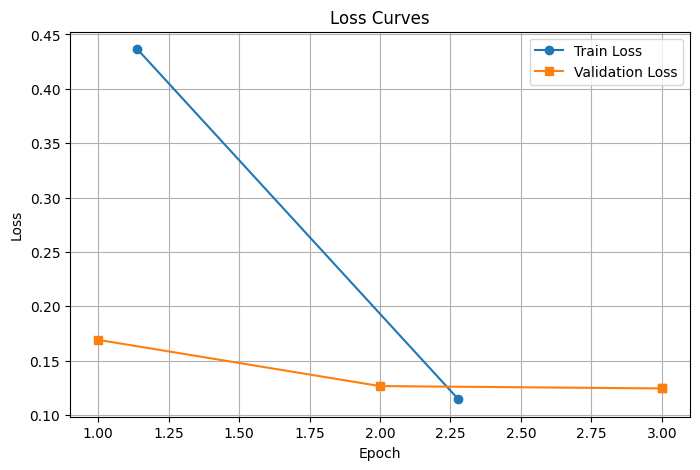

In [41]:
plt.figure(figsize=(8,5))

train_logs = history.dropna(subset=["loss"])
eval_logs = history.dropna(subset=["eval_loss"])

plt.plot(
    train_logs["epoch"],
    train_logs["loss"],
    marker="o",
    label="Train Loss"
)

plt.plot(
    eval_logs["epoch"],
    eval_logs["eval_loss"],
    marker="s",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.legend()
plt.grid(True)

plt.show()

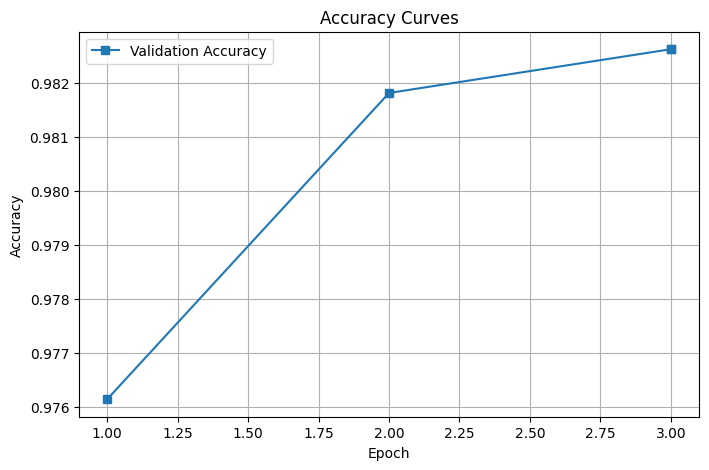

In [44]:
plt.figure(figsize=(8,5))

eval_logs = history.dropna(subset=["eval_accuracy"])


plt.plot(
    eval_logs["epoch"],
    eval_logs["eval_accuracy"],
    marker="s",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curves")
plt.legend()
plt.grid(True)

plt.show()

In [35]:
predictions, labels, _ = trainer.predict(tokenized_datasets["validation"])
predictions = np.argmax(predictions, axis=2)

# Remove ignored index (special tokens)
true_predictions = [
    [label_list[p] for (p, l) in zip(prediction, label) if l != -100]
    for prediction, label in zip(predictions, labels)
]
true_labels = [
    [label_list[l] for (p, l) in zip(prediction, label) if l != -100]
    for prediction, label in zip(predictions, labels)
]

results = metric.compute(predictions=true_predictions, references=true_labels)
results

{'LOC': {'precision': np.float64(0.9462203836028582),
  'recall': np.float64(0.961038961038961),
  'f1': np.float64(0.9535721053628955),
  'number': np.int64(2618)},
 'MISC': {'precision': np.float64(0.8043303929430633),
  'recall': np.float64(0.8147847278635256),
  'f1': np.float64(0.8095238095238095),
  'number': np.int64(1231)},
 'ORG': {'precision': np.float64(0.8790476190476191),
  'recall': np.float64(0.8978599221789884),
  'f1': np.float64(0.888354186717998),
  'number': np.int64(2056)},
 'PER': {'precision': np.float64(0.9712041884816754),
  'recall': np.float64(0.978246539222149),
  'f1': np.float64(0.9747126436781609),
  'number': np.int64(3034)},
 'overall_precision': np.float64(0.9195541822997131),
 'overall_recall': np.float64(0.9322071820114106),
 'overall_f1': np.float64(0.925837453474807),
 'overall_accuracy': 0.9826202996171383}

In [36]:
print(predictions[0])

[0 0 0 3 0 0 0 0 0 0 0 0 5 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 3 3 3 0 0 0 0 0 0
 0 0 0 0 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [39]:
predictions, labels, _ = trainer.predict(tokenized_datasets["validation"])
print(predictions)

[[[ 8.1893911e+00 -1.1929454e+00 -1.2751508e+00 ... -1.8106977e+00
   -6.7823493e-01 -1.6672624e+00]
  [ 8.0807161e+00 -1.4571813e+00 -1.6481619e+00 ... -1.9917439e+00
    6.2567419e-03 -1.7127379e+00]
  [ 8.2829828e+00 -1.4948761e+00 -1.3865511e+00 ... -1.8963399e+00
   -3.5933289e-01 -1.6290675e+00]
  ...
  [-1.0000000e+02 -1.0000000e+02 -1.0000000e+02 ... -1.0000000e+02
   -1.0000000e+02 -1.0000000e+02]
  [-1.0000000e+02 -1.0000000e+02 -1.0000000e+02 ... -1.0000000e+02
   -1.0000000e+02 -1.0000000e+02]
  [-1.0000000e+02 -1.0000000e+02 -1.0000000e+02 ... -1.0000000e+02
   -1.0000000e+02 -1.0000000e+02]]

 [[ 7.9789615e+00 -1.4063638e+00 -1.1534849e+00 ... -1.4491259e+00
   -7.3601276e-01 -1.3294219e+00]
  [-4.3631220e-01 -7.5038695e-01 -1.2469858e+00 ...  6.5417737e-01
   -4.7089744e-01 -1.8014172e+00]
  [ 8.3507357e+00 -1.6683023e+00 -1.0929061e+00 ... -1.3067905e+00
   -9.1757709e-01 -1.0064124e+00]
  ...
  [-1.0000000e+02 -1.0000000e+02 -1.0000000e+02 ... -1.0000000e+02
   -1.0000

In [45]:
from transformers import pipeline

ner = pipeline(
    "token-classification",
    model=model,
    tokenizer=tokenizer,
    aggregation_strategy="simple"
)

text = "John Smith works at Google in California."

print(ner(text))

[{'entity_group': 'LABEL_1', 'score': np.float32(0.99633956), 'word': 'john', 'start': 0, 'end': 4}, {'entity_group': 'LABEL_2', 'score': np.float32(0.99527824), 'word': 'smith', 'start': 5, 'end': 10}, {'entity_group': 'LABEL_0', 'score': np.float32(0.99811125), 'word': 'works at', 'start': 11, 'end': 19}, {'entity_group': 'LABEL_3', 'score': np.float32(0.96924174), 'word': 'google', 'start': 20, 'end': 26}, {'entity_group': 'LABEL_0', 'score': np.float32(0.99456537), 'word': 'in', 'start': 27, 'end': 29}, {'entity_group': 'LABEL_5', 'score': np.float32(0.9895955), 'word': 'california', 'start': 30, 'end': 40}, {'entity_group': 'LABEL_0', 'score': np.float32(0.9985598), 'word': '.', 'start': 40, 'end': 41}]


In [50]:
label_names = datasets["train"].features["ner_tags"].feature.names

print(label_names)

['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']


In [51]:
for i, label in enumerate(label_names):
    print(f"LABEL_{i} -> {label}")

LABEL_0 -> O
LABEL_1 -> B-PER
LABEL_2 -> I-PER
LABEL_3 -> B-ORG
LABEL_4 -> I-ORG
LABEL_5 -> B-LOC
LABEL_6 -> I-LOC
LABEL_7 -> B-MISC
LABEL_8 -> I-MISC


In [53]:
label_map = {
    "LABEL_0": "O",
    "LABEL_1": "B-PER",
    "LABEL_2": "I-PER",
    "LABEL_3": "B-ORG",
    "LABEL_4": "I-ORG",
    "LABEL_5": "B-LOC",
    "LABEL_6": "I-LOC",
}

In [55]:
text = "John Smith works at Google in California."

results = ner(text)

highlighted = text

for entity in results:
    print(
        f"{entity['word']} : "
        f"{label_map.get(entity['entity_group'], entity['entity_group'])}"
    )

print(highlighted)

john : B-PER
smith : I-PER
works at : O
google : B-ORG
in : O
california : B-LOC
. : O
John Smith works at Google in California.
